<a href="https://colab.research.google.com/github/ancestor9/2026_Fall_Deep-Learning-with-Python/blob/main/scripts/chapter12_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Object detection

### Single-stage vs. two-stage object detectors

#### Two-stage R-CNN detectors

#### Single-stage detectors

### Training a YOLO model from scratch

#### Downloading the COCO dataset

In [3]:
import json
import os
import random
import keras
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

N_SAMPLES = 2000  # 실습용 소규모 샘플 수 (필요시 조절)

# 1. annotations(정답 라벨, bounding box, 클래스 라벨 등) 통째로 받아도 빠름 (256MB),  파일 전체 다운로드
annotations_path = keras.utils.get_file(
    "annotations",
    "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
    extract=True,
)
with open(f"{annotations_path}/annotations/instances_train2017.json", "r") as f:
    annotations = json.load(f)

# 2. 이미지 N_SAMPLES개만 랜덤 샘플링
random.seed(42)
sampled_images = random.sample(annotations["images"], N_SAMPLES)
sampled_ids = {img["id"] for img in sampled_images}

annotations["images"] = sampled_images
annotations["annotations"] = [
    ann for ann in annotations["annotations"] if ann["image_id"] in sampled_ids
]

# 3. 샘플링된 이미지만 개별 다운로드, 전체 이미지 목록(약 11만 장) 중 2000장만 무작위 추출
images_path = os.path.expanduser("~/.keras/datasets/coco_sample")
train_dir = os.path.join(images_path, "train2017")
os.makedirs(train_dir, exist_ok=True)

def download_image(img_info):
    dest = os.path.join(train_dir, img_info["file_name"])
    if os.path.exists(dest):
        return
    url = f"http://images.cocodataset.org/train2017/{img_info['file_name']}"
    resp = requests.get(url, timeout=30)
    with open(dest, "wb") as f:
        f.write(resp.content)

# 이미지 다운로드는 대부분 네트워크 대기 시간이라, 16개를 동시에(병렬로) 요청해서 속도를 크게 높임
with ThreadPoolExecutor(max_workers=16) as executor:
    futures = [executor.submit(download_image, img) for img in sampled_images]
    for future in as_completed(futures):
        future.result()

print(f"{N_SAMPLES}장 다운로드 완료")

# 4. images"(이미지 메타정보 리스트: id, 파일명, 가로/세로 크기 등)
images = {image["id"]: image for image in annotations["images"]}

# def scale_box(box, width, height):
#     scale = 1.0 / max(width, height)
#     x, y, w, h = [v * scale for v in box]
#     x += (height - width) * scale / 2 if height > width else 0
#     y += (width - height) * scale / 2 if width > height else 0
#     return [x, y, w, h]

252907541/252907541 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
2000장 다운로드 완료


In [5]:
annotations.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [13]:
# @title **category_id란 ?**
# COCO 데이터셋은 사람, 자동차, 개, 의자 등 80종류의 객체 클래스를 정의해두고, 각 클래스에 고유 번호(id)
annotations["categories"][:5]

[{'supercategory': 'person', 'id': 1, 'name': 'person'},
 {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'}]

In [6]:
metadata = {}

for annotation in annotations["annotations"]:
    id = annotation["image_id"]
    if id not in metadata:
        metadata[id] = {"boxes": [], "labels": []}
    image = images[id]
    box = scale_box(annotation["bbox"], image["width"], image["height"])
    metadata[id]["boxes"].append(box)
    metadata[id]["labels"].append(annotation["category_id"])
    metadata[id]["path"] = train_dir + "/" + image["file_name"]

metadata = list(metadata.values())

### **metadata[0]의 내용**
#### **boxes**
— 이미지 안에 있는 객체 7개의 bounding box 좌표 리스트, 각 박스는 [x, y, w, h] 형태이고:

> - x, y: 박스 좌상단 모서리 위치 (이미지 크기를 0~1로 정규화한 비율)
> - w, h: 박스의 너비, 높이 (역시 0~1 비율)

예를 들어 첫 번째 박스 [0.239, 0.147, 0.428, 0.531]은 "이미지 가로의 23.9% 지점, 세로의 14.7% 지점에서 시작해서, 가로 폭의 42.8%, 세로 높이의 53.1%만큼 차지하는 박스"라는 뜻으로 절대 픽셀 값이 아니라 비율로 저장한 이유는 이미지 크기가 제각각이라도 모델 입력(448×448 정사각형)에 그대로 맞춰 쓸 수 있게 하기 위해서

#### **labels**

— 각 박스가 어떤 클래스인지 나타내는 COCO category_id, boxes와 순서가 1:1로 대응(첫 번째 박스 → label 18, 두 번째 박스 → label 4...)
- 7개 객체: [18, 4, 1, 1, 1, 1, 1]

> - 18 → dog(개)
> - 4 → motorcycle(오토바이)
> - 1 → person(사람), 4번 등장 (사람이 4명 있다는 뜻)

In [8]:
metadata[0]

{'boxes': [[0.23946875, 0.147296875, 0.4284375, 0.530859375],
  [0.077015625, 0.37082812500000006, 0.858484375, 0.47818750000000004],
  [0.6999531250000001, 0.144671875, 0.294796875, 0.404015625],
  [0.0016093750000000001, 0.14296875, 0.10429687500000001, 0.08665625],
  [0.5314375, 0.143421875, 0.169609375, 0.08903125],
  [0.3015625, 0.144625, 0.160140625, 0.1234375],
  [0.44584375, 0.14296875, 0.08268750000000001, 0.053375]],
 'labels': [18, 4, 1, 1, 1, 1, 1],
 'path': '/root/.keras/datasets/coco_sample/train2017/000000263146.jpg'}

In [6]:
# 2000장을 샘플링했지만, annotation이 하나도 없는 이미지(배경만 있거나 라벨이 없는 이미지)는
# metadata 딕셔너리에 아예 추가되지 않으므로 제외
# 그 결과 실제로는 1976장만 metadata에 포함 (2000 - 1976 = 24장은 annotation이 없었던 것)
len(metadata)

1976

In [7]:
# 각 이미지가 가진 박스(객체) 개수 중 최솟값입니다. 즉, 객체가 가장 적은 이미지는 박스가 1개만 있다는 뜻
min([len(x["boxes"]) for x in metadata])

1

In [8]:
# 박스 개수의 최댓값으로 객체가 가장 많은 이미지는 한 장에 무려 50개의 객체가 들어있다는 뜻
# 사람이 많이 찍힌 군중 사진 등일 가능성이 큼
max([len(x["boxes"]) for x in metadata])

50

In [9]:
max(max(x["labels"]) for x in metadata) + 1

91

In [14]:
metadata[435]

{'boxes': [[0.16714062500000001, 0.846921875, 0.032921875, 0.122609375],
  [0.18834375, 0.069984375, 0.40115625000000005, 0.89103125],
  [0.497484375, 0.015765625000000002, 0.33559375, 0.8896406250000001]],
 'labels': [37, 1, 1],
 'path': '/root/.keras/datasets/coco_sample/train2017/000000233968.jpg'}

In [15]:
import keras_hub

[keras_hub.utils.coco_id_to_name(x) for x in metadata[435]["labels"]]

['sports_ball', 'person', 'person']

In [16]:
[keras_hub.utils.coco_id_to_name(x) for x in metadata[0]["labels"]]

['dog', 'motorcycle', 'person', 'person', 'person', 'person', 'person']

4개 함수는 "이미지를 정사각형 좌표계에 맞춰 그리고(draw_image), 그 위에 색깔별로 구분된 박스와 라벨을 그리는(draw_box, label_to_color)" 시각화 도구 세트 다음 셀에서 아마 metadata[0] 같은 샘플 하나를 골라 실제로 그림을 그려볼 것

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from matplotlib.patches import Rectangle

color_map = {0: "gray"}

def scale_box(box, width, height):
    scale = 1.0 / max(width, height)
    x, y, w, h = [v * scale for v in box]
    x += (height - width) * scale / 2 if height > width else 0
    y += (width - height) * scale / 2 if width > height else 0
    return [x, y, w, h]

def label_to_color(label):
    if label not in color_map:
        h, s, v = (len(color_map) * 0.618) % 1, 0.5, 0.9
        color_map[label] = hsv_to_rgb((h, s, v))
    return color_map[label]

def draw_box(ax, box, text, color):
    x, y, w, h = box
    ax.add_patch(Rectangle((x, y), w, h, lw=2, ec=color, fc="none"))
    textbox = dict(fc=color, pad=1, ec="none")
    ax.text(x, y, text, c="white", size=10, va="bottom", bbox=textbox)

def draw_image(ax, image):
    ax.set(xlim=(0, 1), ylim=(1, 0), xticks=[], yticks=[], aspect="equal")
    image = plt.imread(image)
    height, width = image.shape[:2]
    hpad = (1 - height / width) / 2 if width > height else 0
    wpad = (1 - width / height) / 2 if height > width else 0
    extent = [wpad, 1 - wpad, 1 - hpad, hpad]
    ax.imshow(image, extent=extent)

metadata 안에서, 실제로 로컬 디스크에 다운로드가 된 이미지를 하나 찾아서 시각화하는 코드로 원본 노트북의 sample = metadata[435]처럼 인덱스를 고정해서 쓰는 대신, 파일이 실제로 존재하는지 확인 후 그중 하나를 골라 쓰는 안전장치가 추가된 버전

Using metadata index 0 for a valid image: /root/.keras/datasets/coco_sample/train2017/000000263146.jpg


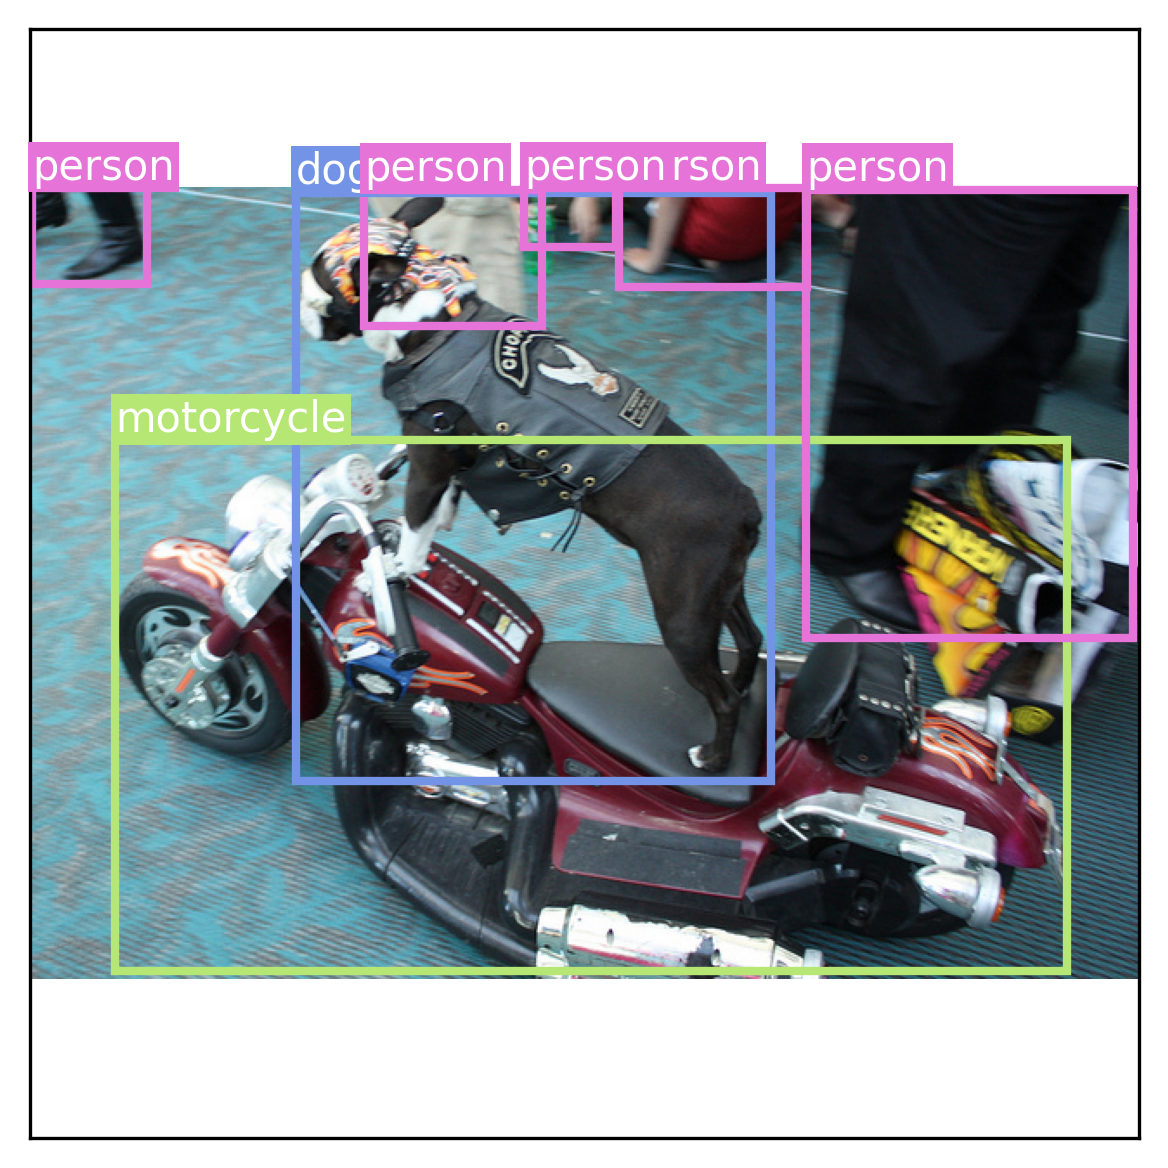

In [18]:
import os
import matplotlib.pyplot as plt

# Find a sample in metadata that actually exists on disk
valid_sample = None
for i, item in enumerate(metadata):
    if os.path.exists(item["path"]):
        valid_sample = item    # 존재하는 이미지 중 가장 앞쪽(가장 작은 인덱스)을 찾는 로직
        print(f"Using metadata index {i} for a valid image: {item['path']}")
        break

if valid_sample is None:
    print("Error: No valid image path found in the current metadata. "
          "This is likely because `metadata` was created from the full COCO dataset annotations "
          "but pointed to a directory with only sampled images. "
          "Please ensure `metadata` refers to actually downloaded images.")
else:
    ig, ax = plt.subplots(dpi=300)
    draw_image(ax, valid_sample["path"])   # 존재하는 이미지 중 가장 앞쪽(가장 작은 인덱스)를 시각화
    for box, label in zip(valid_sample["boxes"], valid_sample["labels"]):
        label_name = keras_hub.utils.coco_id_to_name(label)
        draw_box(ax, box, label_name, label_to_color(label))
    plt.show()

In [14]:
import random

metadata = list(filter(lambda x: len(x["boxes"]) <= 4, metadata))
random.shuffle(metadata)

#### Creating a YOLO model

In [15]:
image_size = 448

backbone = keras_hub.models.Backbone.from_preset(
    "resnet_50_imagenet",
)
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "resnet_50_imagenet",
    image_size=(image_size, image_size),
)

In [16]:
from keras import layers

grid_size = 6
num_labels = 91

inputs = keras.Input(shape=(image_size, image_size, 3))
x = backbone(inputs)
x = layers.Conv2D(512, (3, 3), strides=(2, 2))(x)
x = keras.layers.Flatten()(x)
x = layers.Dense(2048, activation="relu", kernel_initializer="glorot_normal")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(grid_size * grid_size * (num_labels + 5))(x)
x = layers.Reshape((grid_size, grid_size, num_labels + 5))(x)
box_predictions = x[..., :5]
class_predictions = layers.Activation("softmax")(x[..., 5:])
outputs = {"box": box_predictions, "class": class_predictions}
model = keras.Model(inputs, outputs)

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 448, 448,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_net_backbone    │ (None, 14, 14,    │ 23,561,152 │ input_layer_1[0]… │
│ (ResNetBackbone)    │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 6, 6, 512) │  9,437,696 │ res_net_backbone… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 18432)     │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │ 37,750,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3456)      │  7,081,344 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 6, 6, 96)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 6, 6, 91)  │          0 │ reshape[0][0]     │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 6, 6, 5)   │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 6, 6, 91)  │          0 │ get_item_1[0][0]  │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 77,830,976 (296.90 MB)

 Trainable params: 77,777,856 (296.70 MB)

 Non-trainable params: 53,120 (207.50 KB)

#### Readying the COCO data for the YOLO model

In [18]:
def to_grid(box):
    x, y, w, h = box
    cx, cy = (x + w / 2) * grid_size, (y + h / 2) * grid_size
    ix, iy = int(cx), int(cy)
    return (ix, iy), (cx - ix, cy - iy, w, h)

def from_grid(loc, box):
    (xi, yi), (x, y, w, h) = loc, box
    x = (xi + x) / grid_size - w / 2
    y = (yi + y) / grid_size - h / 2
    return (x, y, w, h)

In [19]:
import numpy as np
import math

class_array = np.zeros((len(metadata), grid_size, grid_size))
box_array = np.zeros((len(metadata), grid_size, grid_size, 5))

for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        (x, y, w, h) = box
        left, right = math.floor(x * grid_size), math.ceil((x + w) * grid_size)
        bottom, top = math.floor(y * grid_size), math.ceil((y + h) * grid_size)
        class_array[index, bottom:top, left:right] = label

for index, sample in enumerate(metadata):
    boxes, labels = sample["boxes"], sample["labels"]
    for box, label in zip(boxes, labels):
        (xi, yi), (grid_box) = to_grid(box)
        box_array[index, yi, xi] = [*grid_box, 1.0]
        class_array[index, yi, xi] = label

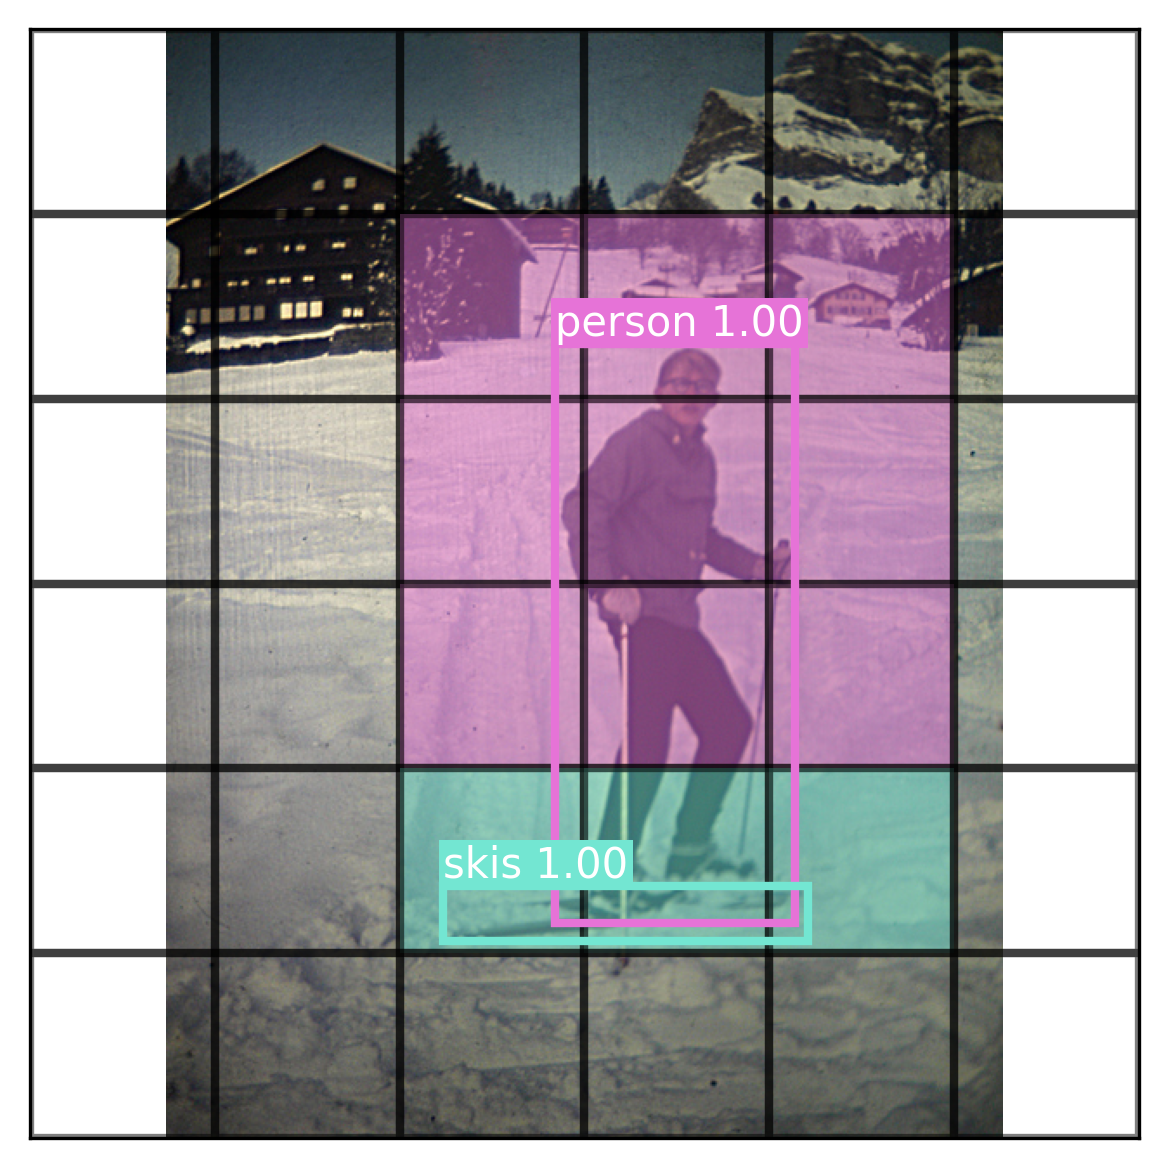

In [20]:
def draw_prediction(image, boxes, classes, cutoff=None):
    fig, ax = plt.subplots(dpi=300)
    draw_image(ax, image)
    for yi, row in enumerate(classes):
        for xi, label in enumerate(row):
            color = label_to_color(label) if label else "none"
            x, y, w, h = (v / grid_size for v in (xi, yi, 1.0, 1.0))
            r = Rectangle((x, y), w, h, lw=2, ec="black", fc=color, alpha=0.5)
            ax.add_patch(r)
    for yi, row in enumerate(boxes):
        for xi, box in enumerate(row):
            box, confidence = box[:4], box[4]
            if not cutoff or confidence >= cutoff:
                box = from_grid((xi, yi), box)
                label = classes[yi, xi]
                color = label_to_color(label)
                name = keras_hub.utils.coco_id_to_name(label)
                draw_box(ax, box, f"{name} {max(confidence, 0):.2f}", color)
    plt.show()

draw_prediction(metadata[0]["path"], box_array[0], class_array[0], cutoff=1.0)

In [21]:
import tensorflow as tf

def load_image(path):
    x = tf.io.read_file(path)
    x = tf.image.decode_jpeg(x, channels=3)
    return preprocessor(x)

images = tf.data.Dataset.from_tensor_slices([x["path"] for x in metadata])
images = images.map(load_image, num_parallel_calls=8)
labels = {"box": box_array, "class": class_array}
labels = tf.data.Dataset.from_tensor_slices(labels)

In [22]:
dataset = tf.data.Dataset.zip(images, labels).batch(16).prefetch(2)
total_batches = dataset.cardinality().numpy()
val_batches = max(1, total_batches // 10)  # 전체의 약 10%를 검증용으로

val_dataset, train_dataset = dataset.take(val_batches), dataset.skip(val_batches)

print(f"전체 {total_batches} batch 중 val={val_batches}, train={total_batches - val_batches}")

전체 64 batch 중 val=6, train=58


#### Training the YOLO model

In [23]:
from keras import ops

def unpack(box):
    return box[..., 0], box[..., 1], box[..., 2], box[..., 3]

def intersection(box1, box2):
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    left = ops.maximum(cx1 - w1 / 2, cx2 - w2 / 2)
    bottom = ops.maximum(cy1 - h1 / 2, cy2 - h2 / 2)
    right = ops.minimum(cx1 + w1 / 2, cx2 + w2 / 2)
    top = ops.minimum(cy1 + h1 / 2, cy2 + h2 / 2)
    return ops.maximum(0.0, right - left) * ops.maximum(0.0, top - bottom)

def intersection_over_union(box1, box2):
    cx1, cy1, w1, h1 = unpack(box1)
    cx2, cy2, w2, h2 = unpack(box2)
    intersection_area = intersection(box1, box2)
    a1 = ops.maximum(w1, 0.0) * ops.maximum(h1, 0.0)
    a2 = ops.maximum(w2, 0.0) * ops.maximum(h2, 0.0)
    union_area = a1 + a2 - intersection_area
    return ops.divide_no_nan(intersection_area, union_area)

In [24]:
def signed_sqrt(x):
    return ops.sign(x) * ops.sqrt(ops.absolute(x) + keras.config.epsilon())

def box_loss(true, pred):
    xy_true, wh_true, conf_true = true[..., :2], true[..., 2:4], true[..., 4:]
    xy_pred, wh_pred, conf_pred = pred[..., :2], pred[..., 2:4], pred[..., 4:]
    no_object = conf_true == 0.0
    xy_error = ops.square(xy_true - xy_pred)
    wh_error = ops.square(signed_sqrt(wh_true) - signed_sqrt(wh_pred))
    iou = intersection_over_union(true, pred)
    conf_target = ops.where(no_object, 0.0, ops.expand_dims(iou, -1))
    conf_error = ops.square(conf_target - conf_pred)
    error = ops.concatenate(
        (
            ops.where(no_object, 0.0, xy_error * 5.0),
            ops.where(no_object, 0.0, wh_error * 5.0),
            ops.where(no_object, conf_error * 0.5, conf_error),
        ),
        axis=-1,
    )
    return ops.sum(error, axis=(1, 2, 3))

In [25]:
print("필터링 후 이미지 수:", len(metadata))
print("전체 배치 수:", dataset.cardinality().numpy())
print("val 배치 수:", val_dataset.cardinality().numpy())
print("train 배치 수:", train_dataset.cardinality().numpy())

필터링 후 이미지 수: 1010
전체 배치 수: 64
val 배치 수: 6
train 배치 수: 58


In [26]:
model.compile(
    optimizer=keras.optimizers.Adam(2e-4),
    loss={"box": box_loss, "class": "sparse_categorical_crossentropy"},
)
model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=4,
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/4
58/58 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - box_loss: 14.7975 - class_loss: 3.5608 - loss: 18.3583 - val_box_loss: 4.4767 - val_class_loss: 3.5805 - val_loss: 8.0573
Epoch 2/4
58/58 ━━━━━━━━━━━━━━━━━━━━ 39s 640ms/step - box_loss: 13.0568 - class_loss: 3.5061 - loss: 16.5629 - val_box_loss: 4.2209 - val_class_loss: 3.7143 - val_loss: 7.9352
Epoch 3/4
58/58 ━━━━━━━━━━━━━━━━━━━━ 36s 588ms/step - box_loss: 6.0360 - class_loss: 3.3507 - loss: 9.3867 - val_box_loss: 2.9986 - val_class_loss: 3.3961 - val_loss: 6.3947
Epoch 4/4
58/58 ━━━━━━━━━━━━━━━━━━━━ 38s 608ms/step - box_loss: 4.4489 - class_loss: 3.0519 - loss: 7.5008 - val_box_loss: 3.1037 - val_class_loss: 3.2850 - val_loss: 6.3888


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


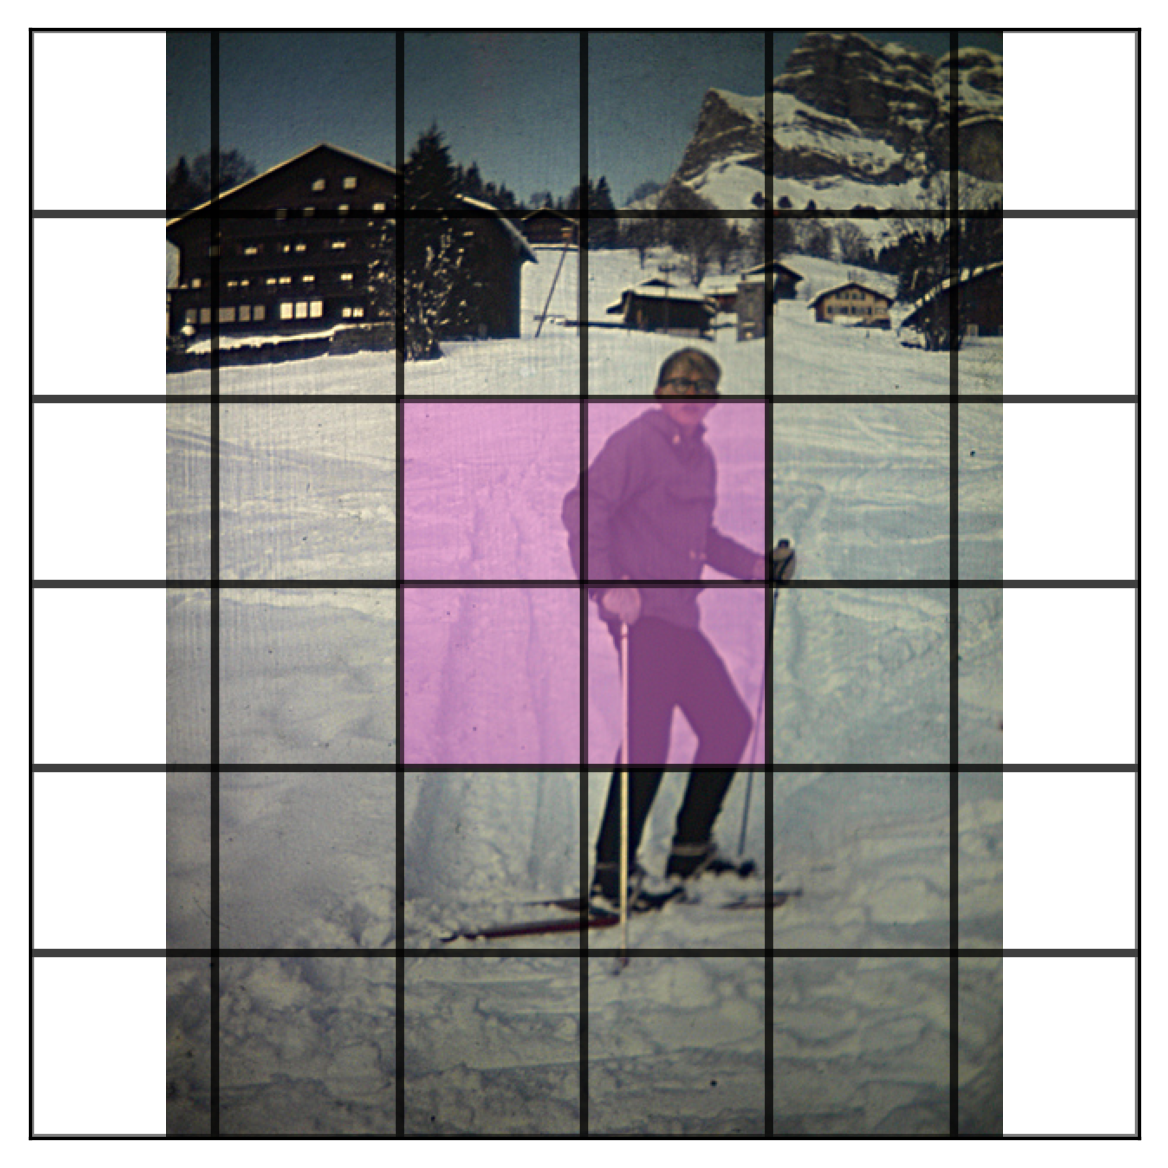

In [27]:
x, y = next(iter(val_dataset.rebatch(1)))
preds = model.predict(x)
boxes = preds["box"][0]
classes = np.argmax(preds["class"][0], axis=-1)
path = metadata[0]["path"]
draw_prediction(path, boxes, classes, cutoff=0.1)

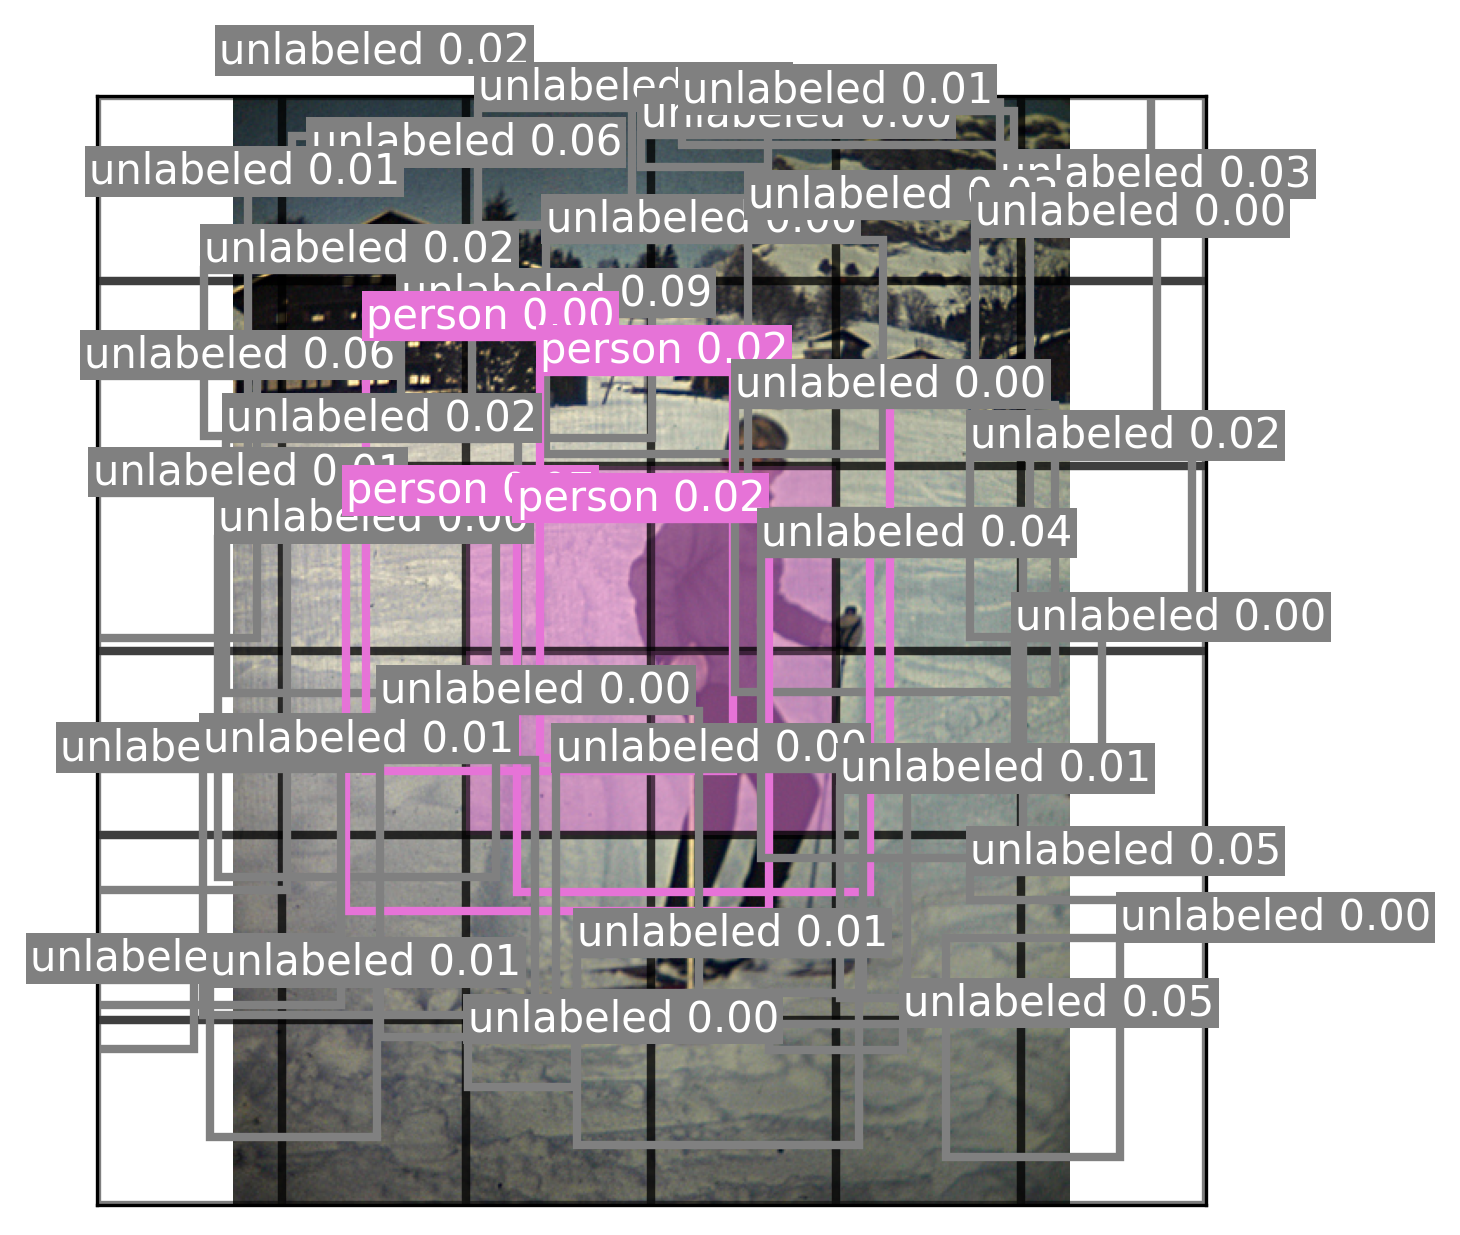

In [28]:
draw_prediction(path, boxes, classes, cutoff=None)

### Using a pretrained RetinaNet detector

In [29]:
url = "https://s3.us-east-1.amazonaws.com/book.keras.io/3e/seurat.jpg"
path = keras.utils.get_file(origin=url)
image = np.array([keras.utils.load_img(path)])

In [30]:
detector = keras_hub.models.ObjectDetector.from_preset(
    "retinanet_resnet50_fpn_v2_coco",
    bounding_box_format="rel_xywh",
)
predictions = detector.predict(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


In [31]:
[(k, v.shape) for k, v in predictions.items()]

[('boxes', (1, 100, 4)),
 ('confidence', (1, 100)),
 ('labels', (1, 100)),
 ('num_detections', (1,))]

In [32]:
predictions["boxes"][0][0]

array([0.02752607, 0.60643774, 0.28109217, 0.16602355], dtype=float32)

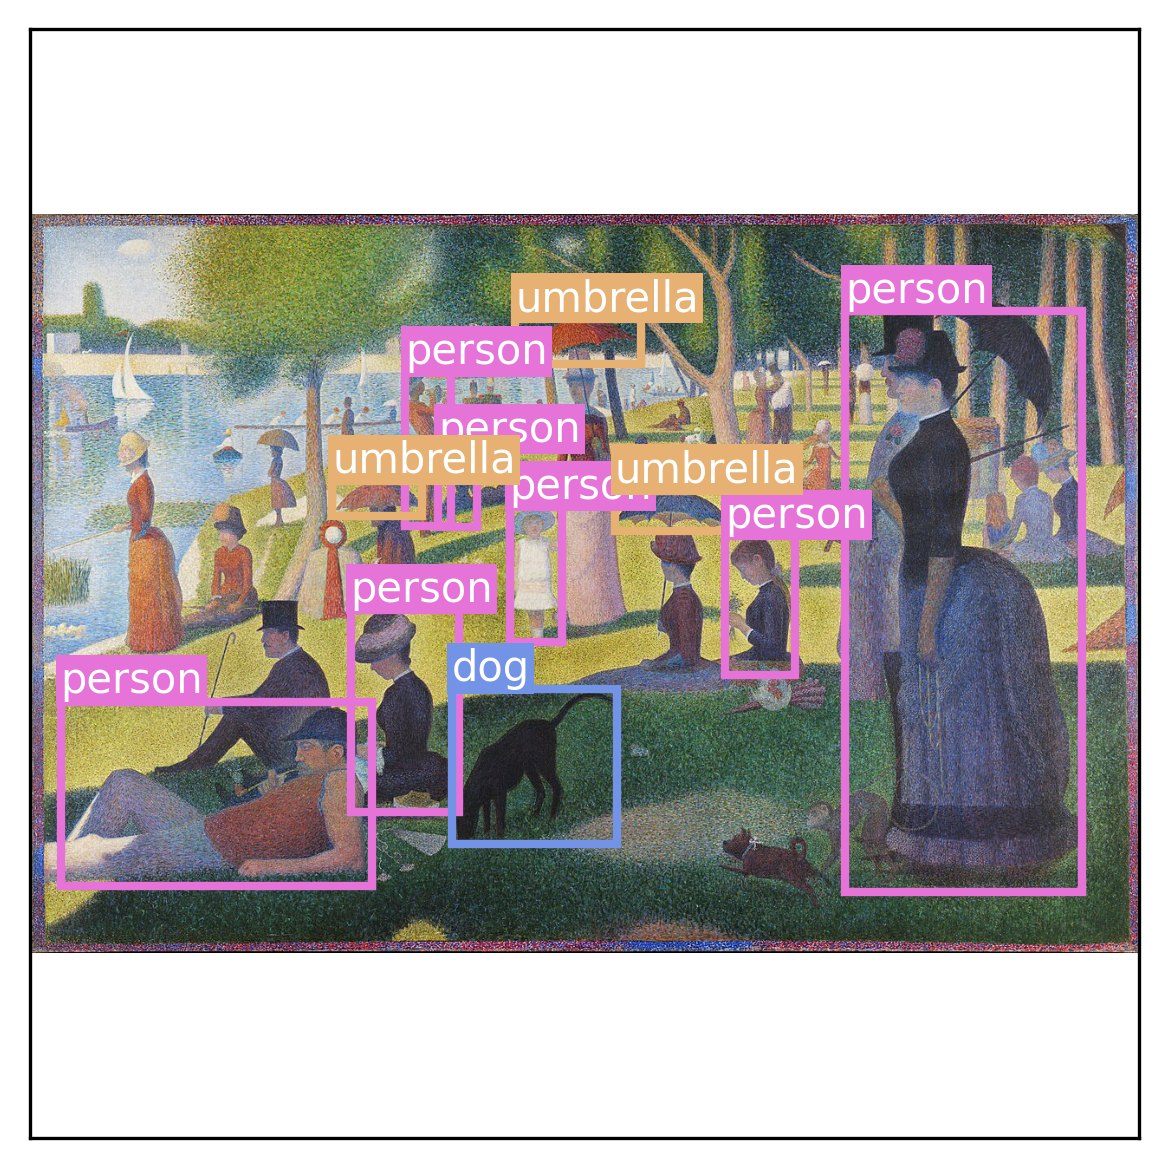

In [33]:
fig, ax = plt.subplots(dpi=300)
draw_image(ax, path)
num_detections = predictions["num_detections"][0]
for i in range(num_detections):
    box = predictions["boxes"][0][i]
    label = predictions["labels"][0][i]
    label_name = keras_hub.utils.coco_id_to_name(label)
    draw_box(ax, box, label_name, label_to_color(label))
plt.show()